In [1]:
import pandas as pd 
import json
import numpy as np 
import datetime as dt
import time
import datetime

import math

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (mean_squared_error, mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error)

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.losses import MeanSquaredError 

import joblib

In [ ]:
# Load data
with open('readings (1).json') as f:
    data = json.load(f)

DEVICE_NORMAL_RANGES = {
    'washing_machine': {'min_power': 500, 'max_power': 2500, 'typical_energy': 1.5},
    'refrigerator': {'min_power': 150, 'max_power': 800, 'typical_energy': 0.3},
    'water_heater': {'min_power': 1500, 'max_power': 4500, 'typical_energy': 3.0},
    'ac': {'min_power': 800, 'max_power': 4000, 'typical_energy': 2.5},
    'tubelight': {'min_power': 15, 'max_power': 60, 'typical_energy': 0.04},
    'fan': {'min_power': 50, 'max_power': 120, 'typical_energy': 0.08},
    'led_light': {'min_power': 5, 'max_power': 25, 'typical_energy': 0.015},
    'tv': {'min_power': 80, 'max_power': 300, 'typical_energy': 0.15},
    'laptop': {'min_power': 30, 'max_power': 150, 'typical_energy': 0.08}
}

In [3]:
def flatten_data(raw_data):
    """Convert nested JSON data to flat DataFrame"""
    rows = []
    for entry in raw_data:
        flat_row = {}
        flat_row['timestamp'] = entry['timestamp']
        for device in entry['devices']:
            name = device['device']
            flat_row[f'{name}_count'] = device['count']
            flat_row[f'{name}_voltage'] = device['voltage']
            flat_row[f'{name}_current'] = device['current']
            flat_row[f'{name}_energy_wh'] = device['energy_wh']
        flat_row['aggregate_energy_wh'] = entry['aggregate_energy_wh']
        rows.append(flat_row)
    return pd.DataFrame(rows)


In [4]:
# Data Preparation
df = flatten_data(data)
df.to_csv("energy_data.csv", index=False)
df = df.sort_values(by='timestamp').reset_index(drop=True)

df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df['hour'] = df['datetime'].dt.hour
df['minute'] = df['datetime'].dt.minute
df['second'] = df['datetime'].dt.second
df.drop(columns=['timestamp', 'datetime'], inplace=True)

In [5]:
# Data Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Train Isolation Forest
iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_model.fit(scaled_data)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [6]:
# Sequence creation
def create_sequences(data, target_index, sequence_length=5):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length][target_index])
    return np.array(X), np.array(y)

target_col = 'aggregate_energy_wh'
target_index = df.columns.get_loc(target_col)

X, y = create_sequences(scaled_data, target_index, sequence_length=5)

In [7]:
# Train-Test Split
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [8]:
# LSTM Model Architecture
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

# Model Compilation and Training
model.compile(optimizer='adam', loss=MeanSquaredError())
model.summary()
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16, verbose=1)

c:\Users\intel\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,841 (155.63 KB)

 Trainable params: 39,841 (155.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - loss: 0.0207 - val_loss: 0.0018
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 4.3496e-05 - val_loss: 0.0011
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - loss: 2.8883e-05 - val_loss: 0.0011
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - loss: 2.2066e-05 - val_loss: 0.0010
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 3.1419e-05 - val_loss: 0.0011
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 1.8790e-05 - val_loss: 9.6034e-04
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 2.4685e-05 - val_loss: 7.1275e-04
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 1.5023e-05 - val_loss: 7.6796e-04
Epoch 9/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 2.5976e-05 - val_loss: 0.0011
Epoch 10/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 2.7845e-05 - val_loss: 3.8785e-04
Epoch 11/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 1.0075e-

In [9]:
y_pred = model.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred) * 100)
print("R² Score:", r2_score(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
MAE : 0.019136950091515302
MSE : 0.0005908098453145626
RMSE: 0.024306580288361475
MAPE: 2.035483479915233
R² Score: 0.8226151083322528


In [10]:
# Save model and scaler
model.save("lstm_energy_model.h5")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(iso_model, "isoforest.pkl")

['isoforest.pkl']

In [11]:
def predict_energy_lstm(new_raw_data, model, scaler):
    df_new = flatten_data(new_raw_data)
    df_new = df_new.sort_values(by='timestamp')
   
    # target column exists
    if 'aggregate_energy_wh' not in df_new.columns:
        df_new['aggregate_energy_wh'] = 0.0



    # columns must match training order -- scale
    scaled_new = scaler.transform(df_new)

    # ensure at least 5 rows; if not, pad by repeating last row
    if len(scaled_new) < 5:
        padding_needed = 5 - len(scaled_new)
        last_row = scaled_new[-1:].repeat(padding_needed, axis=0)
        scaled_new = np.vstack([last_row, scaled_new])

    X_input = np.expand_dims(scaled_new[-5:], axis=0)   # shape (1, 5, features)
    y_scaled_pred = model.predict(X_input)[0][0]


In [12]:
#analyze each device individually
def analyze_device_consumption(device_name, device_data, normal_ranges):
    
    voltage = device_data.get('voltage', 0)
    current = device_data.get('current', 0)
    energy_wh = device_data.get('energy_wh', 0)
    count = device_data.get('count', 0)
    
    # Calculate current power
    current_power = voltage * current
    
    # Get normal ranges for this device
    device_normal = normal_ranges.get(device_name, {})
    min_power = device_normal.get('min_power', 0)
    max_power = device_normal.get('max_power', float('inf'))
    typical_energy = device_normal.get('typical_energy', 0)
    
    # Analysis results
    analysis = {
        'device_name': device_name.replace('_', ' ').title(),
        'current_power': current_power,
        'current_energy': energy_wh,
        'is_active': count > 0,
        'status': 'normal',
        'is_culprit': False,
        'concerns': [],
        'recommendations': []
    }
    
    # Check if device is a culprit based on power consumption
    if current_power > max_power * 1.2:  # 20% above normal maximum
        analysis['status'] = 'high_consumption'
        analysis['is_culprit'] = True
        analysis['concerns'].append(f"Power consumption {current_power:.0f}W is {((current_power/max_power-1)*100):.0f}% above normal max ({max_power}W)")
        analysis['recommendations'].append(f"Check {device_name} for efficiency issues or malfunction")
    
    elif current_power > max_power:
        analysis['status'] = 'above_normal'
        analysis['is_culprit'] = True
        analysis['concerns'].append(f"Power consumption {current_power:.0f}W exceeds normal range ({min_power}-{max_power}W)")
        analysis['recommendations'].append(f"Monitor {device_name} usage and consider maintenance")
    
    elif energy_wh > typical_energy * 2:  # Double the typical energy
        analysis['status'] = 'high_energy'
        analysis['is_culprit'] = True
        analysis['concerns'].append(f"Energy consumption {energy_wh:.3f}Wh is unusually high (typical: {typical_energy:.3f}Wh)")
        analysis['recommendations'].append(f"Reduce {device_name} usage or check for efficiency problems")
    
    elif current_power < min_power * 0.5 and count > 0:  # Too low power when active
        analysis['status'] = 'underperforming'
        analysis['concerns'].append(f"Power consumption {current_power:.0f}W is unusually low - possible malfunction")
        analysis['recommendations'].append(f"Check if {device_name} is working properly")
    
    # Calculate cost impact (assuming 7 INR per kWh)
    daily_cost_impact = (current_power / 1000) * 24 * 7  # Convert to kWh, project daily, multiply by rate
    analysis['daily_cost_impact'] = daily_cost_impact
    
    return analysis

In [13]:
# summary 
def generate_summary(culprit_devices, device_analyses, aggregate_prediction):
    """Generate executive summary answering 'which device is the problem'"""
    
    if not culprit_devices:
        return "✅ All devices are operating normally. No specific device is causing high consumption."
    
    if len(culprit_devices) == 1:
        device_name = culprit_devices[0].replace('_', ' ').title()
        return f"🎯 CULPRIT IDENTIFIED: {device_name} is causing excessive energy consumption. This is the primary reason for your high electricity bill."
    
    # Multiple culprits
    main_culprit = max(culprit_devices, 
                      key=lambda d: device_analyses[d]['daily_cost_impact'])
    main_culprit_name = main_culprit.replace('_', ' ').title()
    
    return f"🚨 MULTIPLE ISSUES: {len(culprit_devices)} devices causing high consumption. PRIMARY CULPRIT: {main_culprit_name}. Other issues: {', '.join([d.replace('_', ' ').title() for d in culprit_devices if d != main_culprit])}"

def generate_action_items(culprit_devices, device_analyses):
    """Generate specific action items for each culprit device"""
    
    if not culprit_devices:
        return ["Continue monitoring. All devices normal."]
    
    actions = []
    actions.append(f"IMMEDIATE ACTION: Focus on {len(culprit_devices)} problematic device(s)")
    
    for device in culprit_devices:
        analysis = device_analyses[device]
        device_name = analysis['device_name']
        cost_impact = analysis['daily_cost_impact']
        
        actions.append(f"• {device_name}: Daily excess cost ₹{cost_impact:.2f} - {'; '.join(analysis['recommendations'])}")
        
        for concern in analysis['concerns']:
            actions.append(f"  ⚠️ {concern}")
    
    return actions

In [14]:
# MAIN FUNCTION that solves specific device 
def comprehensive_device_analysis(new_raw_data, model, scaler):
    
    
    # Get aggregate prediction (existing function)
    aggregate_prediction = predict_energy_lstm(new_raw_data, model, scaler)
    
    # Analyze each device individually
    device_analyses = {}
    culprit_devices = []
    total_device_cost_impact = 0
    
    # Extract device data from input
    for entry in new_raw_data:
        for device_info in entry.get('devices', []):
            device_name = device_info['device']
            
            # Analyze this specific device
            analysis = analyze_device_consumption(device_name, device_info, DEVICE_NORMAL_RANGES)
            device_analyses[device_name] = analysis
            
            # Track culprit devices
            if analysis['is_culprit']:
                culprit_devices.append(device_name)
                total_device_cost_impact += analysis['daily_cost_impact']
    
    # Generate comprehensive report
    report = {
        'timestamp': dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'aggregate_energy_prediction': aggregate_prediction,
        'total_devices_analyzed': len(device_analyses),
        'culprit_devices': culprit_devices,
        'culprit_count': len(culprit_devices),
        'device_analyses': device_analyses,
        'total_excess_cost_per_day': total_device_cost_impact,
        'monthly_excess_cost': total_device_cost_impact * 30,
        'main_culprit': culprit_devices[0] if culprit_devices else None,
        'summary': generate_summary(culprit_devices, device_analyses, aggregate_prediction),
        'action_items': generate_action_items(culprit_devices, device_analyses)
    }
    
    return report

In [15]:
# PREDICTION TEST

print("\n" + "="*80)
print("UTILITYENERGY - DEVICE-WISE CONSUMPTION ANALYSIS")
print("Solving: 'Which device is causing my high electricity bill?'")
print("="*80)

# existing test data
new_raw_data = [
    {
        "timestamp": 1736348345.0,
        "devices": [
            {"device": "washing_machine", "count": 1, "voltage": 226.1, "current": 2.22, "energy_wh": 0.1389},
            {"device": "refrigerator", "count": 1, "voltage": 229.3, "current": 0.62, "energy_wh": 0.0417},
            {"device": "water_heater", "count": 1, "voltage": 219.9, "current": 8.98, "energy_wh": 0.5556},
            {"device": "ac", "count": 2, "voltage": 229.2, "current": 6.48, "energy_wh": 0.8333},
            {"device": "tubelight", "count": 4, "voltage": 221.7, "current": 0.09, "energy_wh": 0.0222},
            {"device": "fan", "count": 3, "voltage": 215.2, "current": 0.23, "energy_wh": 0.0417},
            {"device": "led_light", "count": 5, "voltage": 217.4, "current": 0.05, "energy_wh": 0.0139},
            {"device": "tv", "count": 1, "voltage": 224.8, "current": 0.44, "energy_wh": 0.0278},
            {"device": "laptop", "count": 2, "voltage": 216.4, "current": 0.28, "energy_wh": 0.0333}
        ],
        "aggregate_energy_wh": 0.0
    }
]

# Run the comprehensive analysis
comprehensive_report = comprehensive_device_analysis(new_raw_data, model, scaler)

# Display results in a clear format
print(f" ANALYSIS TIMESTAMP: {comprehensive_report['timestamp']}")
print(f"🔌 AGGREGATE ENERGY PREDICTION: {comprehensive_report['aggregate_energy_prediction']:.4f} Wh")
print(f" DEVICES ANALYZED: {comprehensive_report['total_devices_analyzed']}")

print(f"\n{comprehensive_report['summary']}")

if comprehensive_report['culprit_devices']:
    print(f"\n💰 FINANCIAL IMPACT:")
    print(f"   Daily excess cost: ₹{comprehensive_report['total_excess_cost_per_day']:.2f}")
    print(f"   Monthly excess cost: ₹{comprehensive_report['monthly_excess_cost']:.2f}")
    print(f"   Annual projection: ₹{comprehensive_report['monthly_excess_cost'] * 12:.2f}")

print(f"\n📋 DEVICE-WISE BREAKDOWN:")
print("-" * 80)
print(f"{'Device':<15} | {'Power (W)':<10} | {'Energy (Wh)':<12} | {'Status':<15} | {'Daily Cost ₹':<12}")
print("-" * 80)

for device_name, analysis in comprehensive_report['device_analyses'].items():
    status_icon = "🚨" if analysis['is_culprit'] else "✅"
    print(f"{analysis['device_name']:<15} | {analysis['current_power']:<10.1f} | {analysis['current_energy']:<12.4f} | {status_icon} {analysis['status']:<12} | {analysis['daily_cost_impact']:<12.2f}")

print(f"\n ACTION ITEMS:")
for i, action in enumerate(comprehensive_report['action_items'], 1):
    print(f"{i}. {action}")

print(f"\n 'WHICH DEVICE IS THE CULPRIT?':")
if comprehensive_report['main_culprit']:
    main_culprit_analysis = comprehensive_report['device_analyses'][comprehensive_report['main_culprit']]
    print(f"   PRIMARY CULPRIT: {main_culprit_analysis['device_name']}")
    print(f"   REASON: {'; '.join(main_culprit_analysis['concerns'])}")
    print(f"   SOLUTION: {'; '.join(main_culprit_analysis['recommendations'])}")
else:
    print("   NO CULPRIT FOUND: All devices operating normally")

print("="*80)


UTILITYENERGY - DEVICE-WISE CONSUMPTION ANALYSIS
Solving: 'Which device is causing my high electricity bill?'


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- timestamp
Feature names seen at fit time, yet now missing:
- hour
- minute
- second


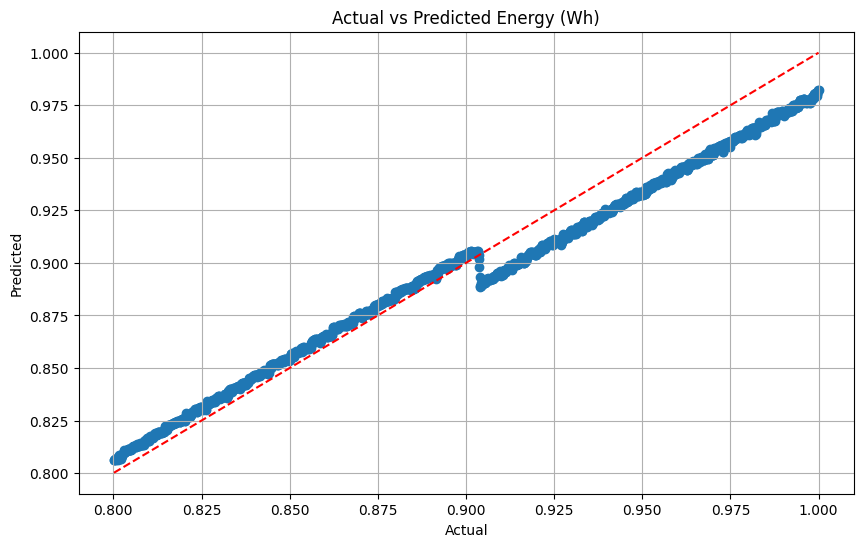

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Energy (Wh)")
plt.grid()
plt.show()